In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
# Read the data and display the head(i.e the top records)
df = pd.read_csv("C:\\Users\\kotip\\Desktop\\Spotify_Hit _Prediction\\data\\spotify.csv")
df.head()

,track,artist,uri,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,target
0,Lucky Man,Montgomery Gentry,spotify:track:4GiXBCUF7H6YfNQsnBRIzl,0.578,0.471,4,-7.270,1,0.0289,0.368000,0.00000,0.159,0.532,133.061,196707,4,30.88059,13,1
1,On The Hotline,Pretty Ricky,spotify:track:1zyqZONW985Cs4osz9wlsu,0.704,0.854,10,-5.477,0,0.1830,0.018500,0.00000,0.148,0.688,92.988,242587,4,41.51106,10,1
2,Clouds Of Dementia,Candlemass,spotify:track:6cHZf7RbxXCKwEkgAZT4mY,0.162,0.836,9,-3.009,1,0.0473,0.000111,0.00457,0.174,0.300,86.964,338893,4,65.32887,13,0
3,"Heavy Metal, Raise Hell!",Zwartketterij,spotify:track:2IjBPp2vMeX7LggzRN3iSX,0.188,0.994,4,-3.745,1,0.1660,0.000007,0.07840,0.192,0.333,148.440,255667,4,58.59528,9,0
4,I Got A Feelin',Billy Currington,spotify:track:1tF370eYXUcWwkIvaq3IGz,0.630,0.764,2,-4.353,1,0.0275,0.363000,0.00000,0.125,0.631,112.098,193760,4,22.62384,10,1


In [73]:
df.tail()

,track,artist,uri,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,target
5867,Summer Rain,Carl Thomas,spotify:track:0NBHHa8wwwmBnn3aAzX5wJ,0.667,0.6270,6,-10.488,0,0.0654,0.0972,0.000052,0.1110,0.784,186.081,232560,4,40.87045,10,1
5868,And I,Ciara,spotify:track:1Jp9n1uHB72CfK31j4mEPh,0.691,0.3890,6,-10.125,1,0.0653,0.2550,0.000000,0.0981,0.437,122.219,233840,4,81.77735,7,1
5869,"Mass in B minor BWV 232, Missa: Duetto - Chris...",Johann Sebastian Bach,spotify:track:4NIOi1ImMfdufRTsgoKjbD,0.297,0.0773,2,-23.839,1,0.0620,0.9510,0.000217,0.1210,0.401,75.916,275560,4,37.51903,11,0
5870,Loog,The Clean,spotify:track:2Qyj2nUdm8y37TCCzDasFn,0.390,0.6010,7,-8.236,0,0.0291,0.0313,0.947000,0.1190,0.439,116.122,223627,4,39.84092,11,0
5871,What The World Needs,Wynonna,spotify:track:38Q6YF0TO7E4Dq6K0zdVUk,0.539,0.7400,0,-5.566,0,0.0490,0.1940,0.000000,0.0760,0.675,170.054,217160,4,24.95471,13,1


In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5872 entries, 0 to 5871
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track             5872 non-null   str    
 1   artist            5872 non-null   str    
 2   uri               5872 non-null   str    
 3   danceability      5872 non-null   float64
 4   energy            5872 non-null   float64
 5   key               5872 non-null   int64  
 6   loudness          5872 non-null   float64
 7   mode              5872 non-null   int64  
 8   speechiness       5872 non-null   float64
 9   acousticness      5872 non-null   float64
 10  instrumentalness  5872 non-null   float64
 11  liveness          5872 non-null   float64
 12  valence           5872 non-null   float64
 13  tempo             5872 non-null   float64
 14  duration_ms       5872 non-null   int64  
 15  time_signature    5872 non-null   int64  
 16  chorus_hit        5872 non-null   float64
 17  sectio

In [75]:
print("Missing Values:\n",df.isnull().sum())
print("\nDuplicate Rows:\n",df.duplicated().sum())

Missing Values:
 track               0
artist              0
uri                 0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
time_signature      0
chorus_hit          0
sections            0
target              0
dtype: int64

Duplicate Rows:
 0


In [76]:
print("shape: ",df.shape)

shape:  (5872, 19)


In [77]:
print("Statistical summary:\n",df.describe())

Statistical summary:
        danceability       energy          key     loudness         mode  \
count   5872.000000  5872.000000  5872.000000  5872.000000  5872.000000   
mean       0.542931     0.694511     5.276396    -7.449258     0.645095   
std        0.190003     0.237792     3.564153     5.102543     0.478525   
min        0.058800     0.000348     0.000000   -47.327000     0.000000   
25%        0.416000     0.567000     2.000000    -8.315000     0.000000   
50%        0.556000     0.744000     5.000000    -6.041500     1.000000   
75%        0.681000     0.885000     8.000000    -4.562500     1.000000   
max        0.986000     0.999000    11.000000     1.137000     1.000000   

       speechiness  acousticness  instrumentalness     liveness      valence  \
count  5872.000000   5872.000000       5872.000000  5872.000000  5872.000000   
mean      0.092360      0.214374          0.150917     0.196141     0.482262   
std       0.094997      0.296511          0.301452     0.16196

In [78]:
print("Target distribution: ")
print(df['target'].value_counts())
print(f"\nHit percentage:{df['target'].mean()*100:.2f} %")

Target distribution: 
target
1    2936
0    2936
Name: count, dtype: int64

Hit percentage:50.00 %


In [79]:
df_new = df.drop(columns=['uri','track','artist'])
print("After dropping columns: ",df_new)

After dropping columns:        danceability  energy  key  loudness  mode  speechiness  acousticness  \
0            0.578  0.4710    4    -7.270     1       0.0289      0.368000   
1            0.704  0.8540   10    -5.477     0       0.1830      0.018500   
2            0.162  0.8360    9    -3.009     1       0.0473      0.000111   
3            0.188  0.9940    4    -3.745     1       0.1660      0.000007   
4            0.630  0.7640    2    -4.353     1       0.0275      0.363000   
...            ...     ...  ...       ...   ...          ...           ...   
5867         0.667  0.6270    6   -10.488     0       0.0654      0.097200   
5868         0.691  0.3890    6   -10.125     1       0.0653      0.255000   
5869         0.297  0.0773    2   -23.839     1       0.0620      0.951000   
5870         0.390  0.6010    7    -8.236     0       0.0291      0.031300   
5871         0.539  0.7400    0    -5.566     0       0.0490      0.194000   

      instrumentalness  liveness  vale

In [80]:
print("Shape of the new dataframe: ",df_new.shape)

Shape of the new dataframe:  (5872, 16)


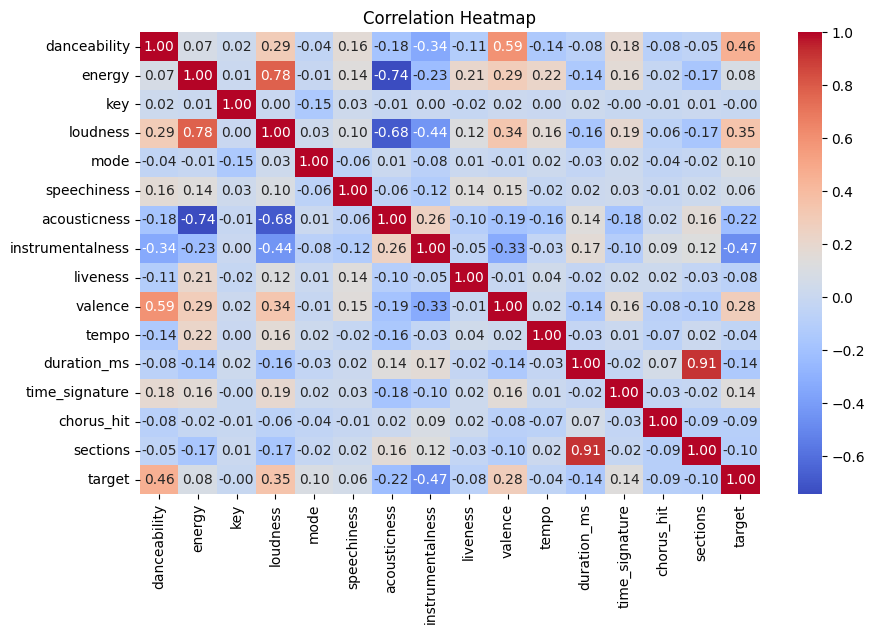

In [81]:
plt.figure(figsize=(10,6))
sns.heatmap(df_new.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [82]:
#save the dataset after dropping columns
df_new.to_csv("C:\\Users\\kotip\\Desktop\\Spotify_Hit _Prediction\\data\\df_new.csv", index=False)

In [83]:
df_new.info()

<class 'pandas.DataFrame'>
RangeIndex: 5872 entries, 0 to 5871
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   danceability      5872 non-null   float64
 1   energy            5872 non-null   float64
 2   key               5872 non-null   int64  
 3   loudness          5872 non-null   float64
 4   mode              5872 non-null   int64  
 5   speechiness       5872 non-null   float64
 6   acousticness      5872 non-null   float64
 7   instrumentalness  5872 non-null   float64
 8   liveness          5872 non-null   float64
 9   valence           5872 non-null   float64
 10  tempo             5872 non-null   float64
 11  duration_ms       5872 non-null   int64  
 12  time_signature    5872 non-null   int64  
 13  chorus_hit        5872 non-null   float64
 14  sections          5872 non-null   int64  
 15  target            5872 non-null   int64  
dtypes: float64(10), int64(6)
memory usage: 734.1 KB


In [84]:
#Check for missing values and duplicates in the new dataframe
print("Missing values in new dataframe:\n",df_new.isnull().sum())
print("\nDuplicate values in new dataframe: ",df_new.duplicated().sum())

Missing values in new dataframe:
 danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
time_signature      0
chorus_hit          0
sections            0
target              0
dtype: int64

Duplicate values in new dataframe:  28


In [85]:
#Drop the duplicates
df_new = df_new.drop_duplicates()
print("After dropping duplicates, shape: ",df_new.shape)

After dropping duplicates, shape:  (5844, 16)


In [86]:
print("Missing values in new dataframe:\n",df_new.isnull().sum())
print("\nDuplicate values in new dataframe: ",df_new.duplicated().sum())

Missing values in new dataframe:
 danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
time_signature      0
chorus_hit          0
sections            0
target              0
dtype: int64

Duplicate values in new dataframe:  0


In [87]:
#Save the cleaned data to a new CSV file
df_new.to_csv("C:\\Users\\kotip\\Desktop\\Spotify_Hit _Prediction\\data\\df_cleaned.csv", index=False)

In [88]:
#shape of the cleaned dataframe
print("Shape of the cleaned dataframe: ",df_new.shape)

Shape of the cleaned dataframe:  (5844, 16)


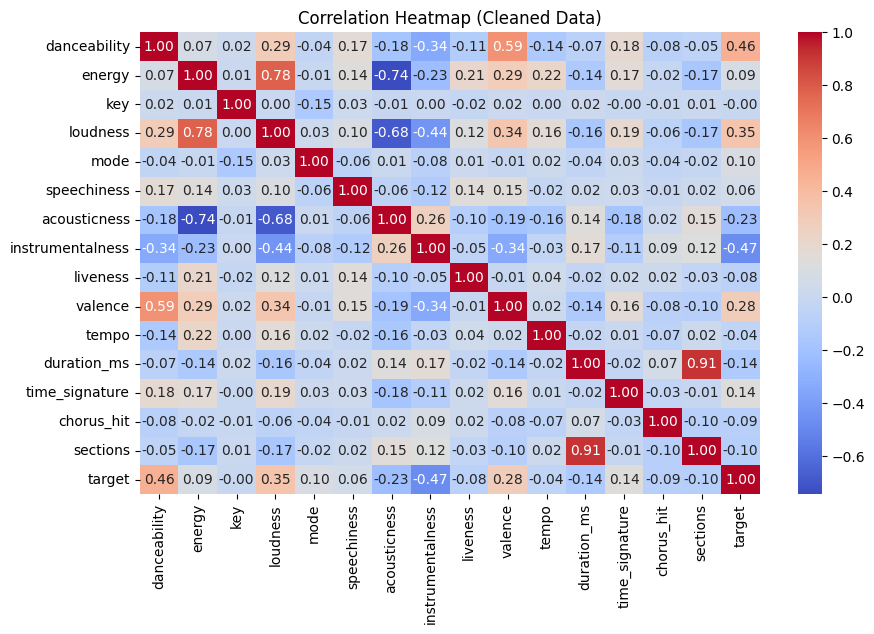

In [89]:
#heatmap of the cleaned dataframe
plt.figure(figsize=(10,6))
sns.heatmap(df_new.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Cleaned Data)")
plt.savefig("C:\\Users\\kotip\\Desktop\\Spotify_Hit _Prediction\\results\\graphs\\correlation_heatmap_cleaned.png", dpi=300, bbox_inches='tight')
plt.show()

In this heat map danceability, instrumentalness are 2 strong predictions in opposite directions.

C:\Users\kotip\AppData\Local\Temp\ipykernel_12476\155444514.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df_new, palette=['red', 'green'])


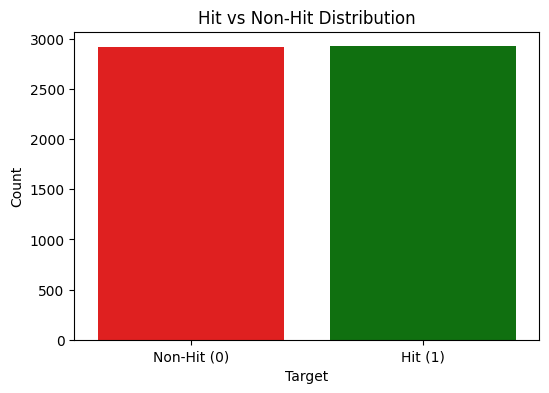

In [90]:
# Exploratory Data Analysis (EDA)
#Target distribution
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df_new, palette=['red', 'green'])
plt.title("Hit vs Non-Hit Distribution")
plt.xticks([0, 1], ['Non-Hit (0)', 'Hit (1)'])
plt.xlabel("Target")
plt.ylabel("Count")
plt.savefig("C:\\Users\\kotip\\Desktop\\Spotify_Hit _Prediction\\results\\graphs\\count_plot.png", dpi=300, bbox_inches='tight')
plt.show()

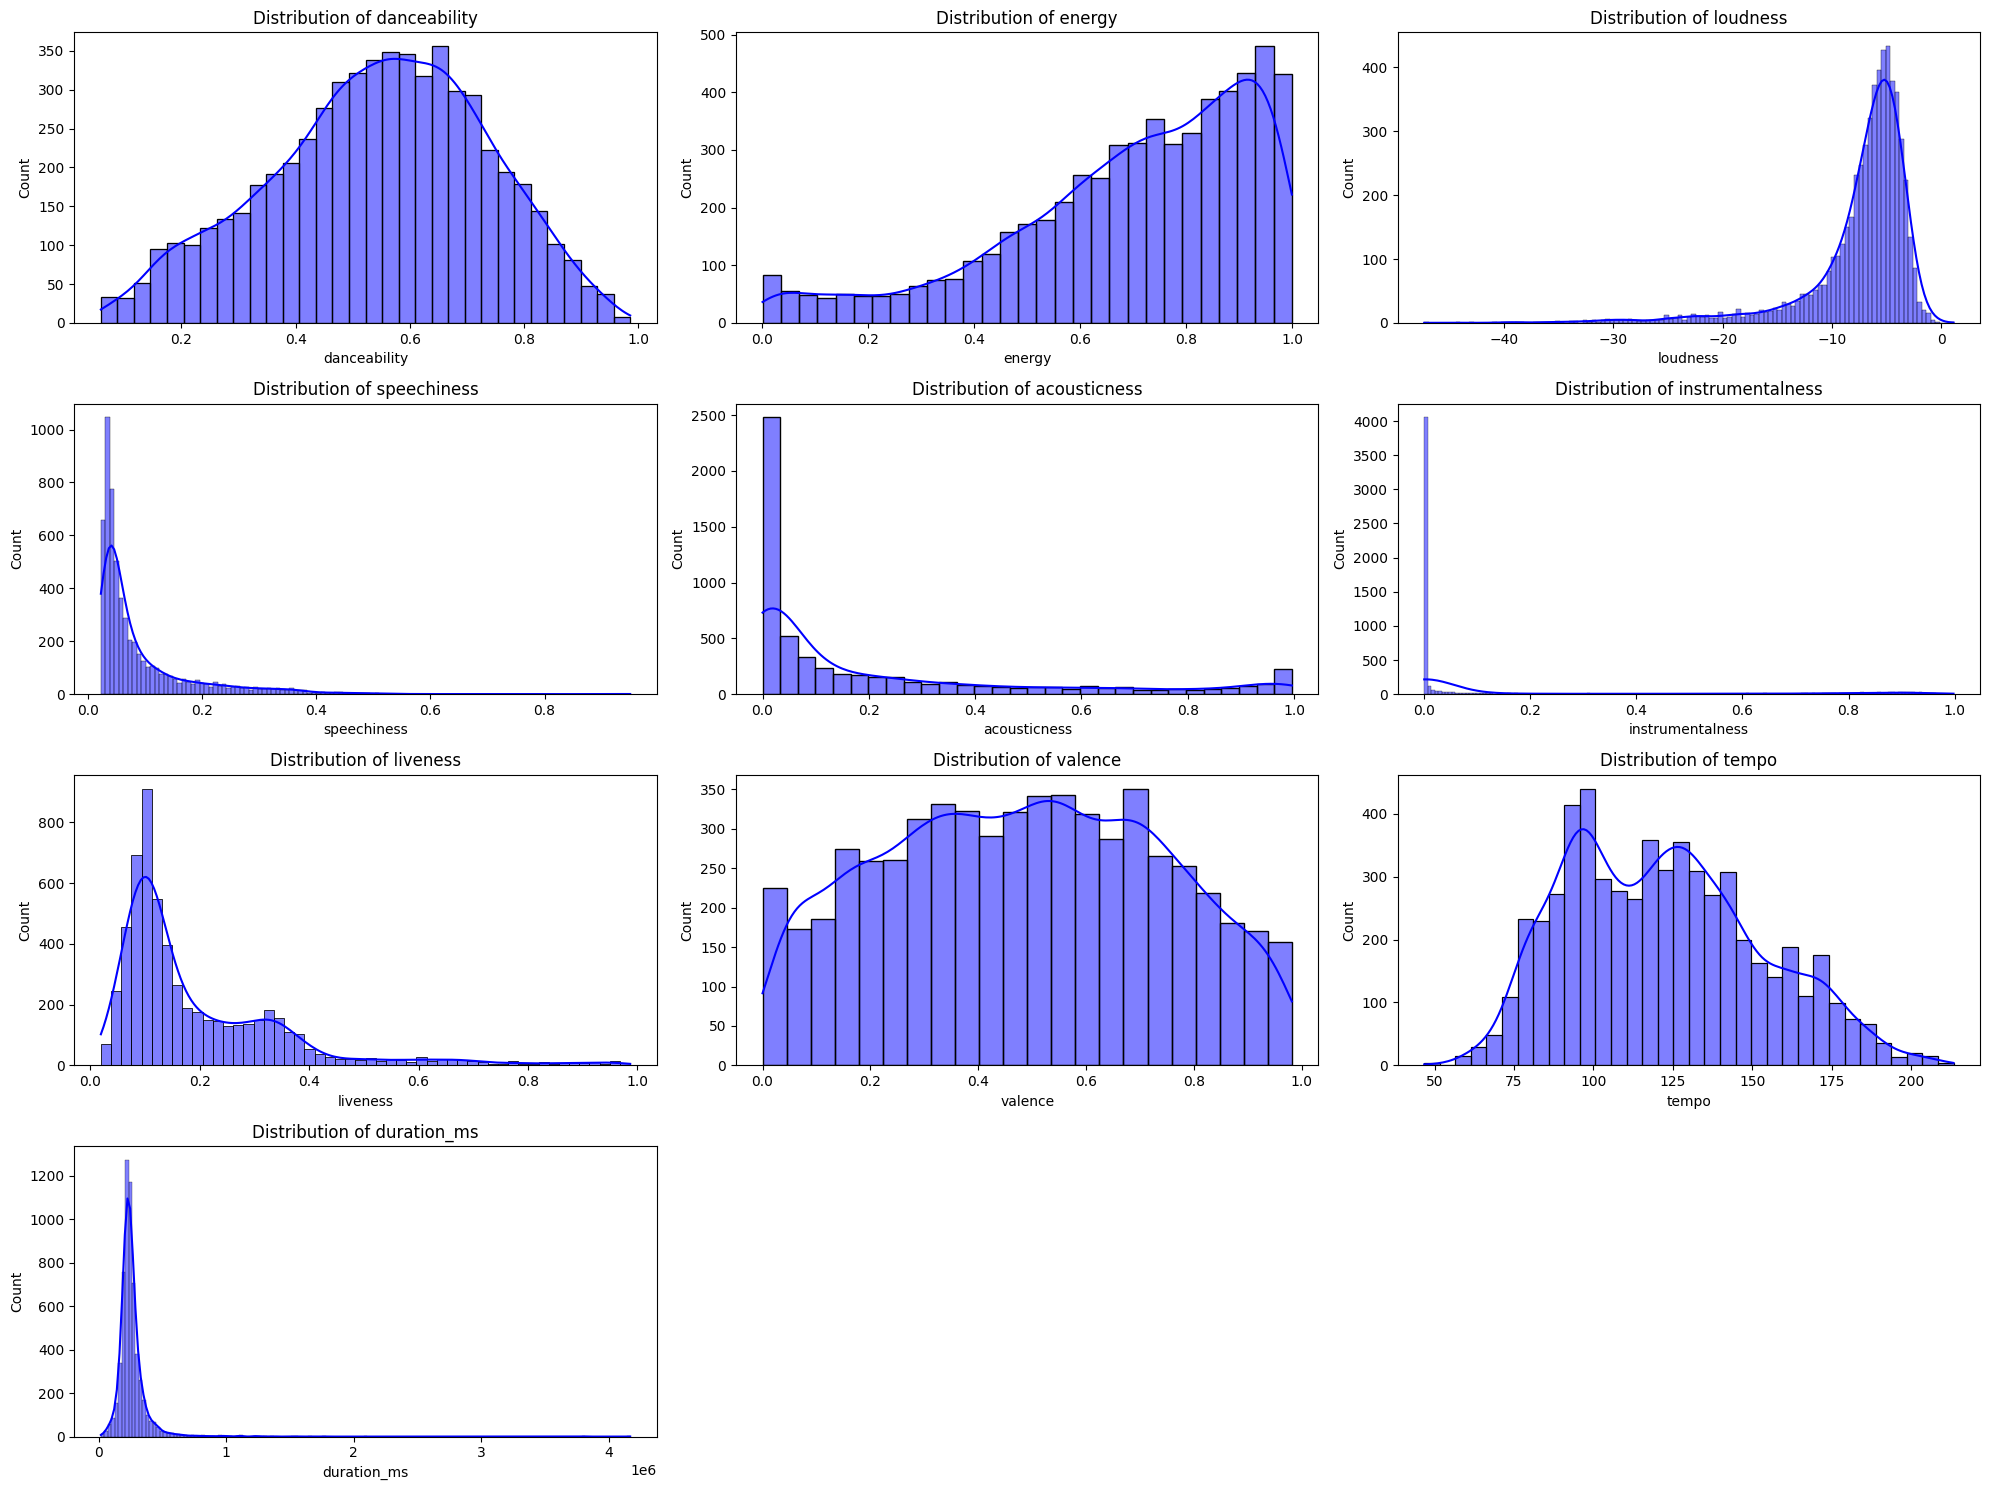

In [91]:
# distribution of numerical features
features = ['danceability', 'energy', 'loudness', 'speechiness','acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']
plt.figure(figsize=(20,15))
for i, feature in enumerate(features):
    plt.subplot(4, 3, i+1)
    sns.histplot(df_new[feature], kde=True, color='blue')
    plt.title(f"Distribution of {feature}")
plt.tight_layout()
plt.savefig("C:\\Users\\kotip\\Desktop\\Spotify_Hit _Prediction\\results\\graphs\\numerical_feature_distributions.png", dpi=300, bbox_inches='tight')
plt.show()

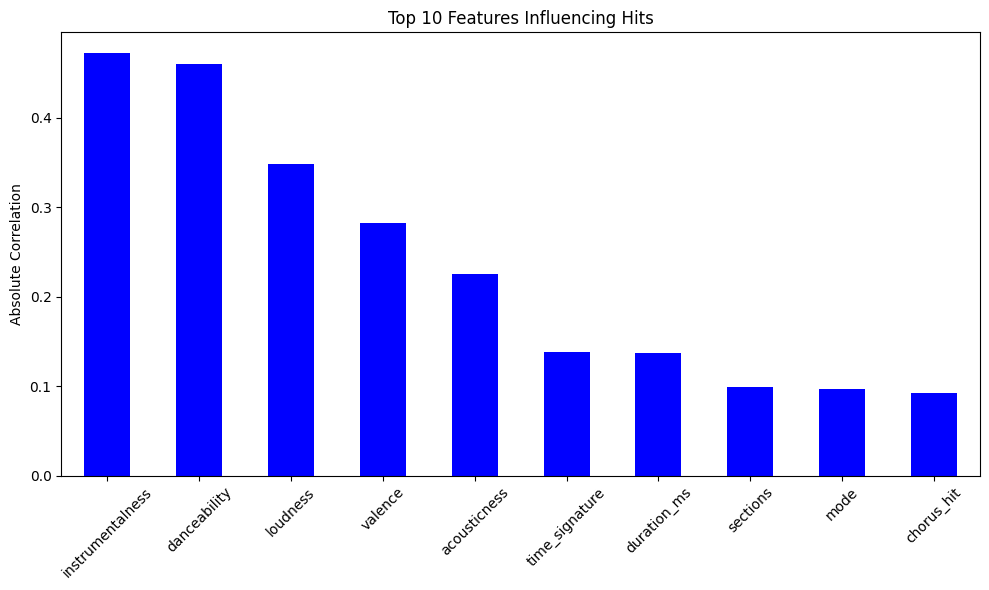

In [92]:
# top 10 features influsing hits
correlation=df_new.corr()['target'].drop('target').abs().sort_values(ascending=False)
plt.figure(figsize=(10,6))
correlation[:10].plot(kind='bar', color='blue')
plt.title("Top 10 Features Influencing Hits")
plt.ylabel("Absolute Correlation")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("C:\\Users\\kotip\\Desktop\\Spotify_Hit _Prediction\\results\\graphs\\top_10_features_influsing.png", dpi=300, bbox_inches='tight')
plt.show()

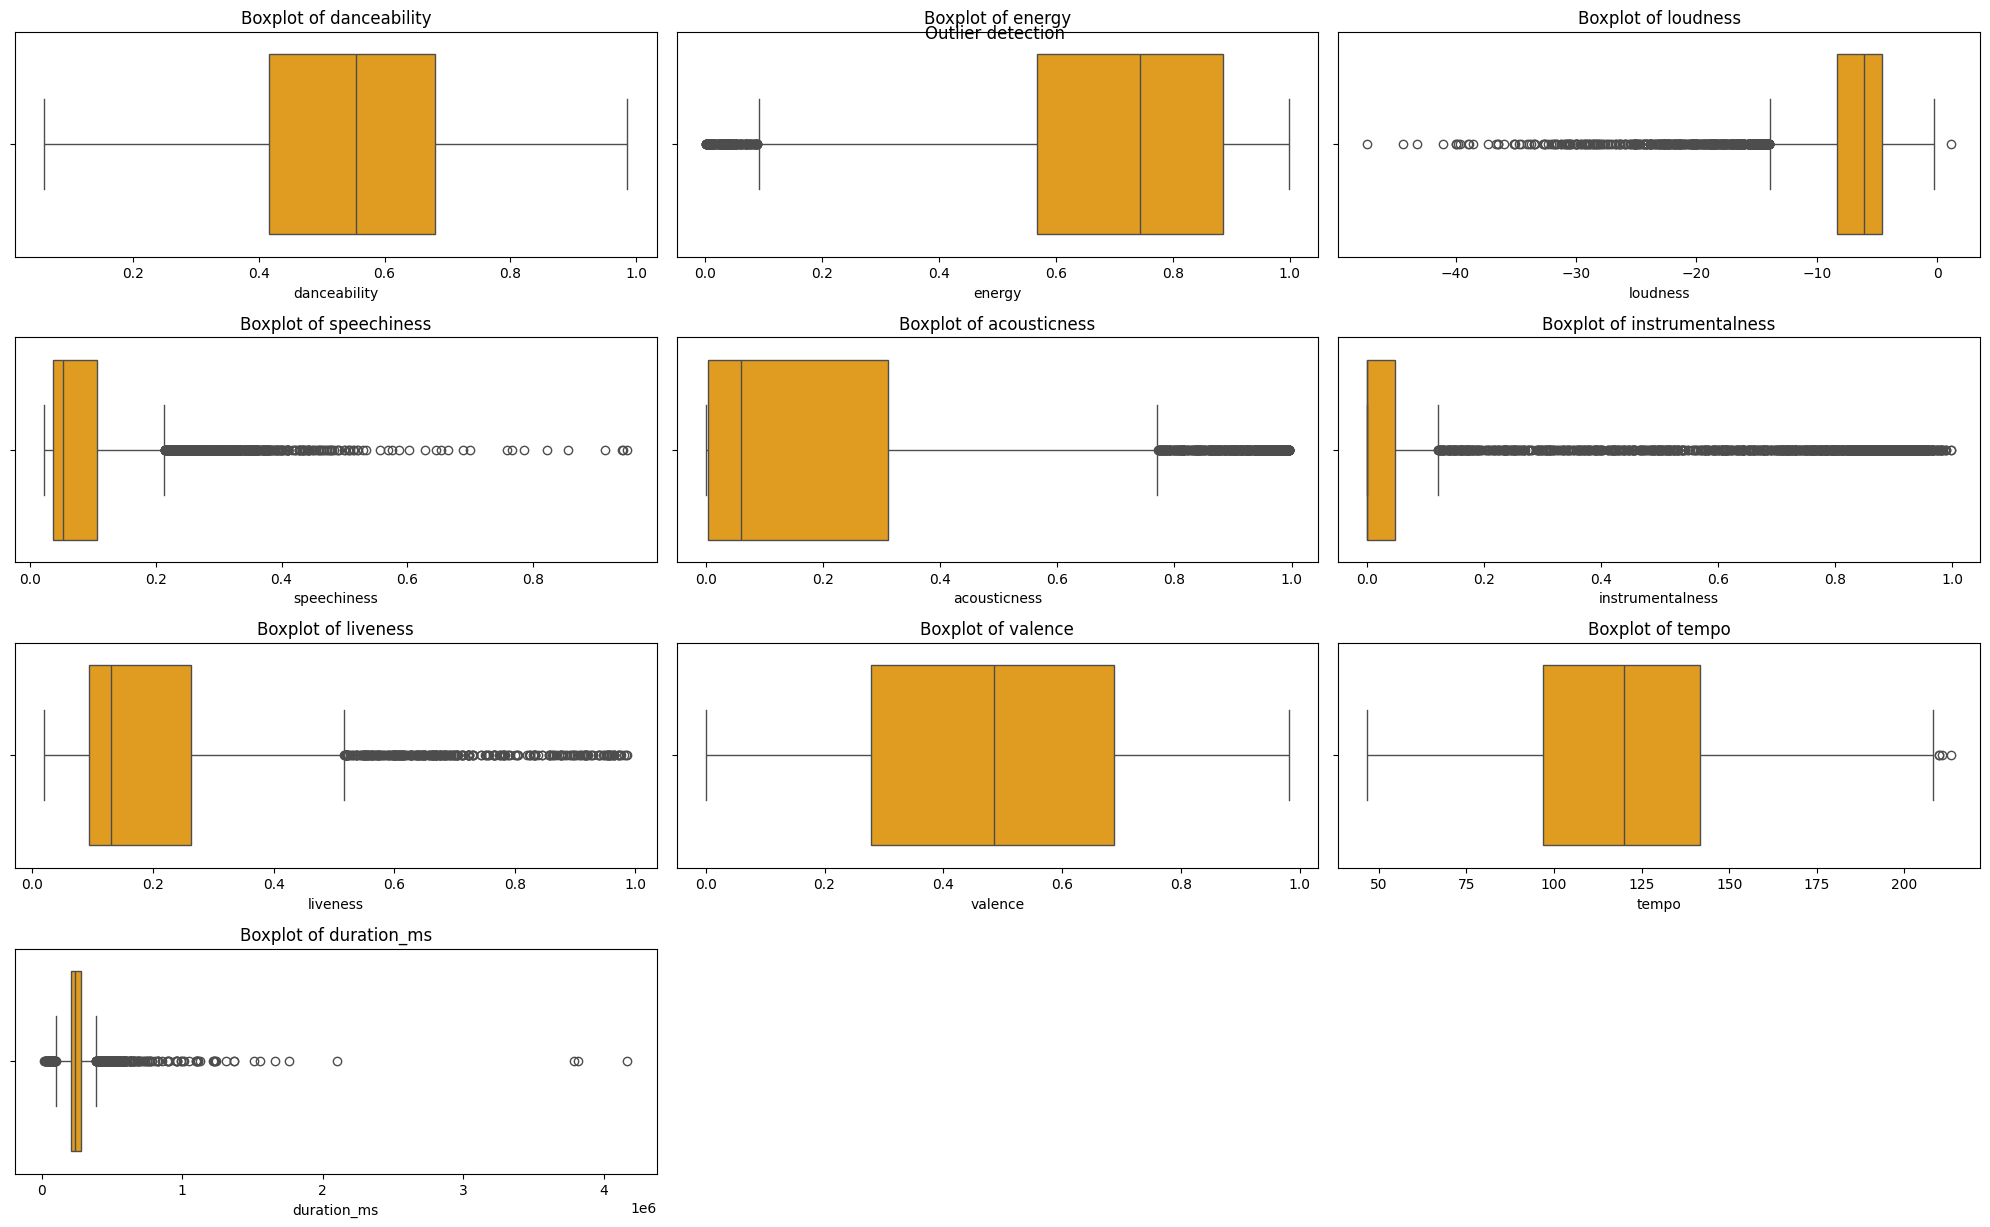

In [93]:
#outliers using boxplot
plt.figure(figsize=(20, 15))
for i, feature in enumerate(features):
    plt.subplot(5, 3, i+1)
    sns.boxplot(x=df_new[feature], color='orange')
    plt.title(f"Boxplot of {feature}")
    plt.tight_layout()

plt.suptitle("Outlier detection")
plt.savefig("C:\\Users\\kotip\\Desktop\\Spotify_Hit _Prediction\\results\\graphs\\boxplots.png",dpi=300,bbox_inches='tight')
plt.show()

In [94]:
df_new.head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,target
0,0.578,0.471,4,-7.270,1,0.0289,0.368000,0.00000,0.159,0.532,133.061,196707,4,30.88059,13,1
1,0.704,0.854,10,-5.477,0,0.1830,0.018500,0.00000,0.148,0.688,92.988,242587,4,41.51106,10,1
2,0.162,0.836,9,-3.009,1,0.0473,0.000111,0.00457,0.174,0.300,86.964,338893,4,65.32887,13,0
3,0.188,0.994,4,-3.745,1,0.1660,0.000007,0.07840,0.192,0.333,148.440,255667,4,58.59528,9,0
4,0.630,0.764,2,-4.353,1,0.0275,0.363000,0.00000,0.125,0.631,112.098,193760,4,22.62384,10,1


Feature Enginnering

In [95]:
from sklearn.preprocessing import StandardScaler

df_clean=pd.read_csv("C:\\Users\\kotip\\Desktop\\Spotify_Hit _Prediction\\data\\df_cleaned.csv")

In [96]:
df_clean.head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,target
0,0.578,0.471,4,-7.270,1,0.0289,0.368000,0.00000,0.159,0.532,133.061,196707,4,30.88059,13,1
1,0.704,0.854,10,-5.477,0,0.1830,0.018500,0.00000,0.148,0.688,92.988,242587,4,41.51106,10,1
2,0.162,0.836,9,-3.009,1,0.0473,0.000111,0.00457,0.174,0.300,86.964,338893,4,65.32887,13,0
3,0.188,0.994,4,-3.745,1,0.1660,0.000007,0.07840,0.192,0.333,148.440,255667,4,58.59528,9,0
4,0.630,0.764,2,-4.353,1,0.0275,0.363000,0.00000,0.125,0.631,112.098,193760,4,22.62384,10,1


In [97]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 5844 entries, 0 to 5843
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   danceability      5844 non-null   float64
 1   energy            5844 non-null   float64
 2   key               5844 non-null   int64  
 3   loudness          5844 non-null   float64
 4   mode              5844 non-null   int64  
 5   speechiness       5844 non-null   float64
 6   acousticness      5844 non-null   float64
 7   instrumentalness  5844 non-null   float64
 8   liveness          5844 non-null   float64
 9   valence           5844 non-null   float64
 10  tempo             5844 non-null   float64
 11  duration_ms       5844 non-null   int64  
 12  time_signature    5844 non-null   int64  
 13  chorus_hit        5844 non-null   float64
 14  sections          5844 non-null   int64  
 15  target            5844 non-null   int64  
dtypes: float64(10), int64(6)
memory usage: 730.6 KB


In [98]:
print(df_clean.shape)

(5844, 16)


In [99]:
x=df_clean.drop(columns=['target'])
y=df_clean['target']

In [100]:
x

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections
0,0.578,0.4710,4,-7.270,1,0.0289,0.368000,0.000000,0.1590,0.532,133.061,196707,4,30.88059,13
1,0.704,0.8540,10,-5.477,0,0.1830,0.018500,0.000000,0.1480,0.688,92.988,242587,4,41.51106,10
2,0.162,0.8360,9,-3.009,1,0.0473,0.000111,0.004570,0.1740,0.300,86.964,338893,4,65.32887,13
3,0.188,0.9940,4,-3.745,1,0.1660,0.000007,0.078400,0.1920,0.333,148.440,255667,4,58.59528,9
4,0.630,0.7640,2,-4.353,1,0.0275,0.363000,0.000000,0.1250,0.631,112.098,193760,4,22.62384,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5839,0.667,0.6270,6,-10.488,0,0.0654,0.097200,0.000052,0.1110,0.784,186.081,232560,4,40.87045,10
5840,0.691,0.3890,6,-10.125,1,0.0653,0.255000,0.000000,0.0981,0.437,122.219,233840,4,81.77735,7
5841,0.297,0.0773,2,-23.839,1,0.0620,0.951000,0.000217,0.1210,0.401,75.916,275560,4,37.51903,11
5842,0.390,0.6010,7,-8.236,0,0.0291,0.031300,0.947000,0.1190,0.439,116.122,223627,4,39.84092,11


In [101]:
y

0       1
1       1
2       0
3       0
4       1
       ..
5839    1
5840    1
5841    0
5842    0
5843    1
Name: target, Length: 5844, dtype: int64

In [102]:
sc=StandardScaler()
x=sc.fit_transform(x)

In [103]:
x

array([[ 0.18556596, -0.94111586, -0.35808085, ...,  0.21217641,
        -0.48664225,  0.34036087],
       [ 0.84925703,  0.66997609,  1.3252208 , ...,  0.21217641,
         0.03779457, -0.18220737],
       [-2.00566802,  0.59425898,  1.04467053, ...,  0.21217641,
         1.2128072 ,  0.34036087],
       ...,
       [-1.29457046, -2.59721743, -0.91918141, ...,  0.21217641,
        -0.15914569, -0.00801796],
       [-0.80470324, -0.39427003,  0.48356997, ...,  0.21217641,
        -0.04459905, -0.00801796],
       [-0.01986222,  0.19043436, -1.48028196, ...,  0.21217641,
        -0.77898583,  0.34036087]], shape=(5844, 15))

In [104]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [105]:
rf=RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [106]:
y_pred=rf.predict(x_test)

In [107]:
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix
acc=accuracy_score(y_test,y_pred)
print("Accuracy: ",acc)
print("Classification Report:\n",classification_report(y_test,y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))

Accuracy:  0.8460222412318221
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.84      0.84       564
           1       0.85      0.85      0.85       605

    accuracy                           0.85      1169
   macro avg       0.85      0.85      0.85      1169
weighted avg       0.85      0.85      0.85      1169

Confusion Matrix:
 [[474  90]
 [ 90 515]]


In [108]:
imp=pd.DataFrame({'Feature':df_clean.columns[:-1], 'Importance':rf.feature_importances_})
imp=imp.sort_values(by='Importance',ascending=False,ignore_index=True)
print(imp)

             Feature  Importance
0   instrumentalness    0.210797
1       danceability    0.125654
2        duration_ms    0.098541
3           loudness    0.097945
4       acousticness    0.092135
5             energy    0.076350
6            valence    0.064231
7        speechiness    0.051314
8              tempo    0.039709
9           liveness    0.037876
10        chorus_hit    0.037273
11          sections    0.034476
12               key    0.021938
13              mode    0.007435
14    time_signature    0.004326


C:\Users\kotip\AppData\Local\Temp\ipykernel_12476\3271768763.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=imp, palette='viridis')


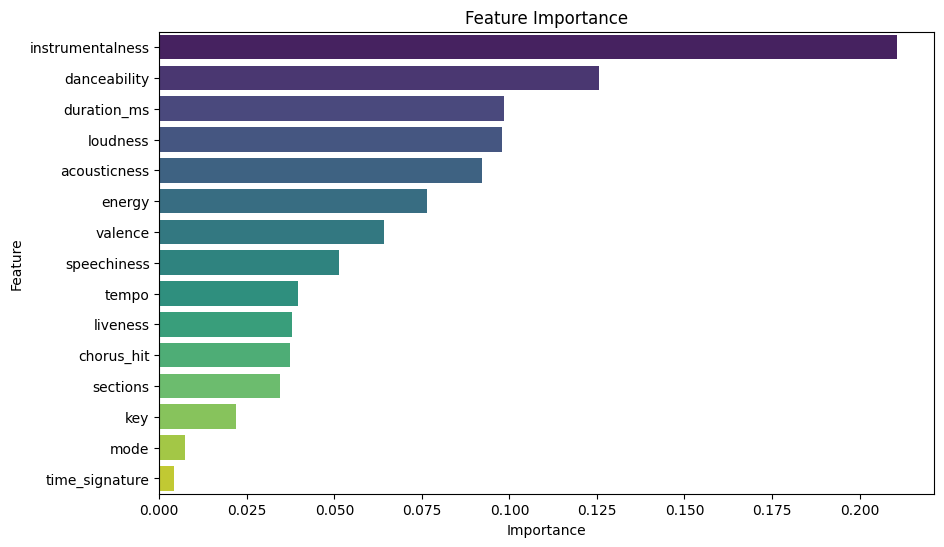

In [109]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=imp, palette='viridis')
plt.title("Feature Importance")
plt.savefig("C:\\Users\\kotip\\Desktop\\Spotify_Hit _Prediction\\results\\graphs\\feature_importance.png", dpi=300)
plt.show()

In [110]:
low_imp=["mode","time_signature"]
x_redused=df_clean.drop(columns=low_imp+['target'])
y=df_clean['target']
x_train,x_test,y_train,y_test=train_test_split(x_redused,y,test_size=0.2,random_state=42)
rf.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [111]:
y_pred2=rf.predict(x_test)

In [112]:
acc2=accuracy_score(y_test,y_pred2)
print("Accuracy after removing low importance features: ",acc2)

Accuracy after removing low importance features:  0.8511548331907614


In [113]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, ConfusionMatrixDisplay

In [114]:
x=df_clean.drop(columns=['target', 'time_signature', 'mode'])
y=df_clean['target']

In [115]:
sc=StandardScaler()
x_scaled=sc.fit_transform(x)

In [116]:
X_train, X_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [117]:
kfold=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [118]:
results=[]

In [119]:
# logistic regression
lr=LogisticRegression(random_state=42, max_iter=1000)
#SVM
svm=SVC(random_state=42)
#randomforest
rf=RandomForestClassifier(n_estimators=100, random_state=42)

In [120]:
cv=cross_val_score(lr, X_train, y_train, cv=kfold, scoring='accuracy')

print("Cross-validation scores: ", cv)
print("Logistic Regression Accuracy: ", cv.mean())
print("Standard Deviation: ", cv.std())

Cross-validation scores:  [0.83101604 0.79786096 0.81604278 0.81925134 0.79893048]
Logistic Regression Accuracy:  0.8126203208556151
Standard Deviation:  0.012643864561396068


In [121]:
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [122]:
y_pred_lr=lr.predict(X_test)

In [123]:
acc_lr=accuracy_score(y_test, y_pred_lr)
prec_lr=precision_score(y_test, y_pred_lr)
recall_lr=recall_score(y_test, y_pred_lr)
f1_lr=f1_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy: ", acc_lr)
print("Logistic Regression Precision: ", prec_lr)
print("Logistic Regression Recall: ", recall_lr)
print("Logistic Regression F1-Score: ", f1_lr)

Logistic Regression Accuracy:  0.8331907613344739
Logistic Regression Precision:  0.7963525835866262
Logistic Regression Recall:  0.8957264957264958
Logistic Regression F1-Score:  0.8431214802896219


Confusion Matrix:
 [[450 134]
 [ 61 524]]


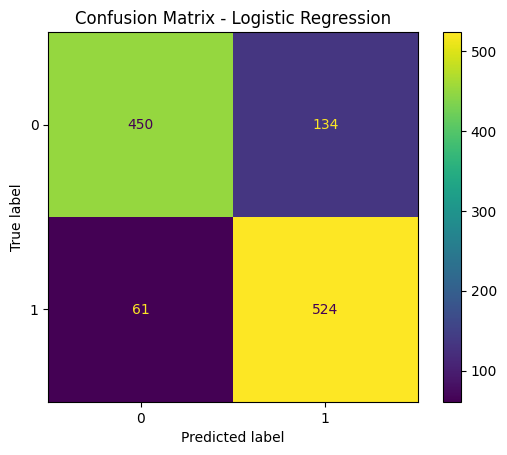

In [124]:
cm_lr=confusion_matrix(y_test, y_pred_lr)
print("Confusion Matrix:\n", cm_lr)
disp=ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.savefig("C:\\Users\\kotip\\Desktop\\Spotify_Hit _Prediction\\results\\confusion_matrices\\confusion_matrix_lr.png", dpi=300, bbox_inches='tight')
plt.show()

In [125]:
results.append({
    'Model': 'Logistic Regression',
    "cross_val_score mean": cv.mean(),
    'Accuracy': acc_lr,
    'Precision': prec_lr,
    'Recall': recall_lr,
    'F1-Score': f1_lr,
    'Confusion Matrix': cm_lr
})

In [126]:
#SVM
cv_svm=cross_val_score(svm, X_train, y_train, cv=kfold, scoring='accuracy')
print("SVM Cross-validation scores: ", cv_svm)
print("SVM Accuracy: ", cv_svm.mean())

SVM Cross-validation scores:  [0.85240642 0.85240642 0.84812834 0.85668449 0.82245989]
SVM Accuracy:  0.8464171122994651


In [127]:
svm.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [128]:
y_pred_svm=svm.predict(X_test)

In [129]:
acc_svm=accuracy_score(y_test, y_pred_svm)
prec_svm=precision_score(y_test, y_pred_svm)
recall_svm=recall_score(y_test, y_pred_svm)
f1_svm=f1_score(y_test, y_pred_svm)

print("SVM Accuracy: ", acc_svm)
print("SVM Precision: ", prec_svm)
print("SVM Recall: ", recall_svm)
print("SVM F1-Score: ", f1_svm)

SVM Accuracy:  0.8460222412318221
SVM Precision:  0.8026905829596412
SVM Recall:  0.9179487179487179
SVM F1-Score:  0.8564593301435407


SVM Confusion Matrix:
 [[452 132]
 [ 48 537]]


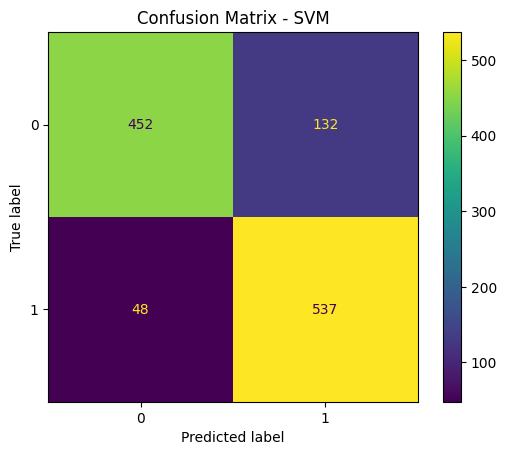

In [130]:
cm_svm=confusion_matrix(y_test, y_pred_svm)
print("SVM Confusion Matrix:\n", cm_svm)
disp=ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp.plot()
plt.title("Confusion Matrix - SVM")
plt.savefig("C:\\Users\\kotip\\Desktop\\Spotify_Hit _Prediction\\results\\confusion_matrices\\confusion_matrix_svm.png", dpi=300, bbox_inches='tight')
plt.show()

In [131]:
results.append({
    'Model': 'SVM',
    "cross_val_score mean": cv_svm.mean(),
    'Accuracy': acc_svm,
    'Precision': prec_svm,
    'Recall': recall_svm,
    'F1-Score': f1_svm,
    'Confusion Matrix': cm_svm
})

In [132]:
#Random Forest
cv_rf=cross_val_score(rf, X_train, y_train, cv=kfold, scoring='accuracy')
print("Random Forest Cross-validation scores: ", cv_rf)
print("Random Forest Accuracy: ", cv_rf.mean())

Random Forest Cross-validation scores:  [0.86096257 0.84278075 0.85882353 0.85454545 0.8459893 ]
Random Forest Accuracy:  0.8526203208556149


In [133]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [142]:
import joblib 
joblib.dump(rf, "C:\\Users\\kotip\\Desktop\\Spotify_Hit _Prediction\\models\\random_forest_model.pkl")
joblib.dump(sc, "C:\\Users\\kotip\\Desktop\\Spotify_Hit _Prediction\\models\\scaler.pkl")

print("Random Forest model and scaler saved successfully.")

Random Forest model and scaler saved successfully.


In [ ]:
df

In [135]:
y_pred_rf=rf.predict(X_test)

In [136]:
acc_rf=accuracy_score(y_test, y_pred_rf)
prec_rf=precision_score(y_test, y_pred_rf)
recall_rf=recall_score(y_test, y_pred_rf)
f1_rf=f1_score(y_test, y_pred_rf)

print("Random Forest Accuracy: ", acc_rf)
print("Random Forest Precision: ", prec_rf)
print("Random Forest Recall: ", recall_rf)
print("Random Forest F1-Score: ", f1_rf)

Random Forest Accuracy:  0.8460222412318221
Random Forest Precision:  0.8369384359400999
Random Forest Recall:  0.8598290598290599
Random Forest F1-Score:  0.8482293423271501


Random Forest Confusion Matrix:
 [[486  98]
 [ 82 503]]


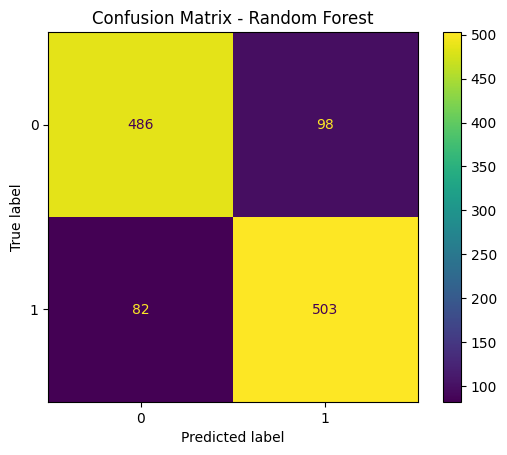

In [137]:
cm_rf=confusion_matrix(y_test, y_pred_rf)
print("Random Forest Confusion Matrix:\n", cm_rf)
disp=ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.savefig("C:\\Users\\kotip\\Desktop\\Spotify_Hit _Prediction\\results\\confusion_matrices\\confusion_matrix_rf.png", dpi=300, bbox_inches='tight')
plt.show()

In [138]:
results.append({
    'Model': 'Random Forest',
    "cross_val_score mean": cv_rf.mean(),
    'Accuracy': acc_rf,
    'Precision': prec_rf,
    'Recall': recall_rf,
    'F1-Score': f1_rf,
    'Confusion Matrix': cm_rf
})

In [139]:
comparison_df=pd.DataFrame(results)
comparison_df

,Model,cross_val_score mean,Accuracy,Precision,Recall,F1-Score,Confusion Matrix
0,Logistic Regression,0.812620,0.833191,0.796353,0.895726,0.843121,"[[450, 134], [61, 524]]"
1,SVM,0.846417,0.846022,0.802691,0.917949,0.856459,"[[452, 132], [48, 537]]"
2,Random Forest,0.852620,0.846022,0.836938,0.859829,0.848229,"[[486, 98], [82, 503]]"


In [143]:
comparison_df.sort_values(by='Accuracy', ascending=False, ignore_index=True)

,Model,cross_val_score mean,Accuracy,Precision,Recall,F1-Score,Confusion Matrix
0,SVM,0.846417,0.846022,0.802691,0.917949,0.856459,"[[452, 132], [48, 537]]"
1,Random Forest,0.852620,0.846022,0.836938,0.859829,0.848229,"[[486, 98], [82, 503]]"
2,Logistic Regression,0.812620,0.833191,0.796353,0.895726,0.843121,"[[450, 134], [61, 524]]"


Now, let's the saved_model with original_model

In [154]:
load_model=joblib.load("C:\\Users\\kotip\\Desktop\\Spotify_Hit _Prediction\\models\\random_forest_model.pkl")

In [157]:
original_pred = rf.predict(X_test[:10])
loaded_pred = load_model.predict(X_test[:10])

print("Orignal_model_predictions: ",original_pred)
print("Loaded_model_predictions:  ",loaded_pred)

Orignal_model_predictions:  [0 0 1 1 1 0 1 0 1 1]
Loaded_model_predictions:   [0 0 1 1 1 0 1 0 1 1]
